In [4]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import precision_score, recall_score, f1_score, matthews_corrcoef

from sklearn.ensemble import IsolationForest
from sklearn.cluster import DBSCAN
from sklearn.neighbors import LocalOutlierFactor

import warnings
warnings.filterwarnings("ignore")

# 1- Defining Normal vs. Anomalous Data

In [5]:
benign = pd.read_csv("Datasense\\benign_samples_10sec.csv")
botnet = pd.read_csv("Datasense\\attack_samples_10sec.csv")

benign['label'] = 0
botnet['label'] = 1

df = pd.concat([benign, botnet], ignore_index=True)

In [6]:
df['label'].value_counts()
df['label'].unique()

array([0, 1])

In [7]:
from sklearn.utils import resample

# Separate classes
normal = df[df['label'] == 0]
anomaly = df[df['label'] == 1]

print("Normal:", len(normal))
print("Anomaly (original):", len(anomaly))
print("Target anomaly:", int(len(normal) * 0.05 / 0.90))

# Oversample anomaly to reach ~10%
n_anomaly_target = int(len(normal) * 0.05 / 0.90)

anomaly_upsampled = resample(
    anomaly,
    replace=True,   
    n_samples=n_anomaly_target,
    random_state=42
)

# Combine + shuffle
df_balanced = pd.concat([normal, anomaly_upsampled])
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

Normal: 13680
Anomaly (original): 16350
Target anomaly: 760


In [8]:
df_balanced['label'].value_counts(normalize=True)

label
0    0.947368
1    0.052632
Name: proportion, dtype: float64

In [9]:
df_balanced.head()

,device_name,device_mac,label_full,label1,label2,label3,label4,timestamp,timestamp_start,timestamp_end,...,network_time-delta_std_deviation,network_ttl_avg,network_ttl_max,network_ttl_min,network_ttl_std_deviation,network_window-size_avg,network_window-size_max,network_window-size_min,network_window-size_std_deviation,label
0,ultrasonic-sensor,08:b6:1f:82:ee:c4,benign_whole-network3,benign,benign,benign,benign,2025-09-09T14:25:50.400000Z_2025-09-09T14:26:0...,2025-09-09T14:25:50.400000Z,2025-09-09T14:26:00.400000Z,...,0.029067,159.5,255.0,64.0,95.5,34841.0,64062.0,5620.0,29221.0,0
1,edge1,dc:a6:32:dc:27:d4,benign_whole-network3,benign,benign,benign,benign,2025-09-09T14:40:50.400000Z_2025-09-09T14:41:0...,2025-09-09T14:40:50.400000Z,2025-09-09T14:41:00.400000Z,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
2,soil-sensor,f0:08:d1:ce:cf:0c,benign_whole-network3,benign,benign,benign,benign,2025-09-09T15:06:10.400000Z_2025-09-09T15:06:2...,2025-09-09T15:06:10.400000Z,2025-09-09T15:06:20.400000Z,...,0.034023,159.5,255.0,64.0,95.5,34801.0,64062.0,5540.0,29261.0,0
3,motion-sensor,08:b6:1f:82:1c:3c,benign_whole-network3,benign,benign,benign,benign,2025-09-09T14:22:20.400000Z_2025-09-09T14:22:3...,2025-09-09T14:22:20.400000Z,2025-09-09T14:22:30.400000Z,...,0.007500,159.5,255.0,64.0,95.5,34846.5,64067.0,5626.0,29220.5,0
4,soil-sensor,f0:08:d1:ce:cf:0c,benign_whole-network3,benign,benign,benign,benign,2025-09-09T14:42:10.400000Z_2025-09-09T14:42:2...,2025-09-09T14:42:10.400000Z,2025-09-09T14:42:20.400000Z,...,0.059375,159.5,255.0,64.0,95.5,34825.0,64062.0,5588.0,29237.0,0


## Feature selection

In [10]:
features = df.columns.tolist()
print(features)

['device_name', 'device_mac', 'label_full', 'label1', 'label2', 'label3', 'label4', 'timestamp', 'timestamp_start', 'timestamp_end', 'log_data-ranges_avg', 'log_data-ranges_max', 'log_data-ranges_min', 'log_data-ranges_std_deviation', 'log_data-types', 'log_data-types_count', 'log_interval-messages', 'log_messages_count', 'network_fragmentation-score', 'network_fragmented-packets', 'network_header-length_avg', 'network_header-length_max', 'network_header-length_min', 'network_header-length_std_deviation', 'network_interval-packets', 'network_ip-flags_avg', 'network_ip-flags_max', 'network_ip-flags_min', 'network_ip-flags_std_deviation', 'network_ip-length_avg', 'network_ip-length_max', 'network_ip-length_min', 'network_ip-length_std_deviation', 'network_ips_all', 'network_ips_all_count', 'network_ips_dst', 'network_ips_dst_count', 'network_ips_src', 'network_ips_src_count', 'network_macs_all', 'network_macs_all_count', 'network_macs_dst', 'network_macs_dst_count', 'network_macs_src', '

In [11]:
cols_to_keep = [
    # keep only useful features
    "network_packet-size_avg",
    "network_payload-length_avg",
    "network_time-delta_avg",
    "network_tcp-flags-syn_count",
    "network_fragmentation-score",
    'label'  # keep label if you have one
]

df_clean = df_balanced[cols_to_keep]

In [12]:
X = df_clean.drop(columns=['label'])
y = df_clean['label']

In [13]:
df_clean.head()

,network_packet-size_avg,network_payload-length_avg,network_time-delta_avg,network_tcp-flags-syn_count,network_fragmentation-score,label
0,63.913043,10.5,0.020980,0,0.0,0
1,0.000000,0.0,0.000000,0,0.0,0
2,62.272727,8.5,0.021431,0,0.0,0
3,61.000000,8.0,0.005409,0,0.0,0
4,62.083333,8.5,0.033498,0,0.0,0


# 2- Apply the following anomaly detection algorithms covered in class:

- Isolation Forest
- DBSCAN
- Local Outlier Factor (LOF)

Train your models using the feature data only (no labels)

# 3- Converting Model Output to Predictions
# 4- Model Evaluation (Using Ground Truth Labels)

In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## Isolation Forest

In [15]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(
    n_estimators=100,
    max_samples='auto',
    contamination=0.05,
    random_state=42
)

iso.fit(X_scaled)

iso_pred = iso.predict(X_scaled)
iso_pred = [1 if x == -1 else 0 for x in iso_pred]

In [16]:
from sklearn.metrics import precision_score, recall_score, f1_score, matthews_corrcoef

y_true = df_clean['label']

def evaluate_model(y_true, y_pred, model_name):
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    mcc = matthews_corrcoef(y_true, y_pred)

    print(f"{model_name}")
    print(f"Precision: {precision:.3f}")
    print(f"Recall:    {recall:.3f}")
    print(f"F1-score:  {f1:.3f}")
    print(f"MCC:       {mcc:.3f}")
    print("Anomalies predicted:", sum(y_pred))
    print("-" * 30)

evaluate_model(y_true, iso_pred, "Isolation Forest")

Isolation Forest
Precision: 0.276
Recall:    0.262
F1-score:  0.269
MCC:       0.229
Anomalies predicted: 722
------------------------------


## BDSCAN

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
import numpy as np

db_data = df_clean[cols_to_keep + ['label']].copy()
X_db = db_data[cols_to_keep]
y_db = db_data['label']

sample_size = 50000

if len(db_data) > sample_size:
    X_db_s, _, y_db_s, _ = train_test_split(
        X_db,
        y_db,
        train_size=sample_size,
        stratify=y_db,
        random_state=42
    )
else:
    X_db_s = X_db.copy()
    y_db_s = y_db.copy()

scaler = StandardScaler()
X_db_scaled = scaler.fit_transform(X_db_s)

db = DBSCAN(eps=0.8, min_samples=5, n_jobs=-1)
db_labels = db.fit_predict(X_db_scaled)

db_pred = np.where(db_labels == -1, 1, 0)

In [22]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score, matthews_corrcoef

print("y_db_s shape:", np.asarray(y_db_s).shape)
print("db_pred shape:", np.asarray(db_pred).shape)

y_db_s shape: (14440, 2)
db_pred shape: (14440,)


In [23]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score, matthews_corrcoef

y_true = np.asarray(y_db_s)[:, 1]   # anomaly column
y_pred = np.asarray(db_pred)

precision = precision_score(y_true, y_pred, zero_division=0)
recall = recall_score(y_true, y_pred, zero_division=0)
f1 = f1_score(y_true, y_pred, zero_division=0)
mcc = matthews_corrcoef(y_true, y_pred)

print("DBSCAN")
print(f"Precision: {precision:.3f}")
print(f"Recall:    {recall:.3f}")
print(f"F1-score:  {f1:.3f}")
print(f"MCC:       {mcc:.3f}")
print("Anomalies predicted:", sum(y_pred))
print("-" * 30)

DBSCAN
Precision: 0.613
Recall:    0.025
F1-score:  0.048
MCC:       0.116
Anomalies predicted: 31
------------------------------


## LOF

In [58]:
from sklearn.neighbors import LocalOutlierFactor

lof = LocalOutlierFactor(
    n_neighbors=15,
    contamination=0.05
)

lof_pred = lof.fit_predict(X_scaled)
lof_pred = [1 if x == -1 else 0 for x in lof_pred]

In [59]:
from sklearn.metrics import precision_score, recall_score, f1_score, matthews_corrcoef

y_true = df_clean['label']

def evaluate_model(y_true, y_pred, model_name):
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    mcc = matthews_corrcoef(y_true, y_pred)

    print(f"{model_name}")
    print(f"Precision: {precision:.3f}")
    print(f"Recall:    {recall:.3f}")
    print(f"F1-score:  {f1:.3f}")
    print(f"MCC:       {mcc:.3f}")
    print("Anomalies predicted:", sum(y_pred))
    print("-" * 30)

evaluate_model(y_true, lof_pred, "LOF")


LOF
Precision: 0.359
Recall:    0.068
F1-score:  0.115
MCC:       0.138
Anomalies predicted: 145
------------------------------


# test

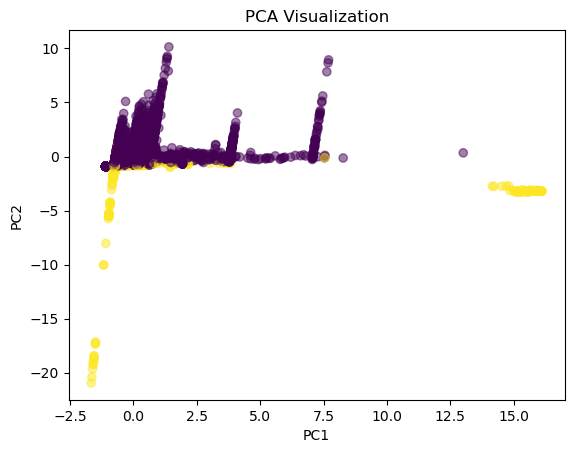

In [60]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)  # try 5–10
X_pca = pca.fit_transform(X_scaled)

# Plot
plt.figure()
plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=df_clean['label'],   # color by label
    alpha=0.5
)

plt.title("PCA Visualization")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

## Isolation Forest

In [61]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(
    n_estimators=100,
    contamination=0.01,
    random_state=42
)

iso.fit(X_pca)

iso_pred = iso.predict(X_pca)
iso_pred = [1 if x == -1 else 0 for x in iso_pred]

In [62]:
from sklearn.metrics import precision_score, recall_score, f1_score, matthews_corrcoef

y_true = df_clean['label']

def evaluate_model(y_true, y_pred, model_name):
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    mcc = matthews_corrcoef(y_true, y_pred)

    print(f"{model_name}")
    print(f"Precision: {precision:.3f}")
    print(f"Recall:    {recall:.3f}")
    print(f"F1-score:  {f1:.3f}")
    print(f"MCC:       {mcc:.3f}")
    print("Anomalies predicted:", sum(y_pred))
    print("-" * 30)

evaluate_model(y_true, iso_pred, "Isolation Forest (PCA)")

Isolation Forest (PCA)
Precision: 0.604
Recall:    0.114
F1-score:  0.192
MCC:       0.248
Anomalies predicted: 144
------------------------------


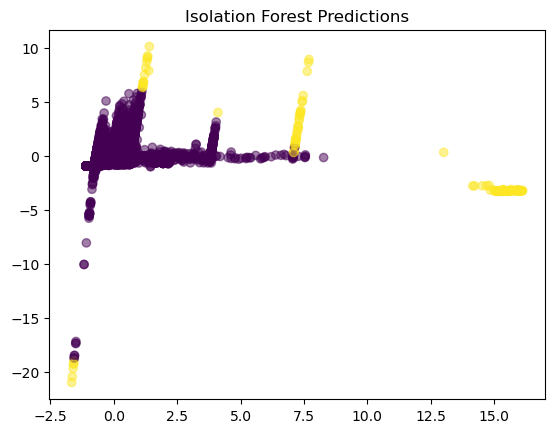

In [63]:
plt.figure()
plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=iso_pred,   # model predictions
    alpha=0.5
)

plt.title("Isolation Forest Predictions")
plt.show()

In [64]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(
    eps=0.5,        # distance threshold (tune this!)
    min_samples=5   # minimum points to form a cluster
)

db_labels = dbscan.fit_predict(X_pca)

# Convert to anomaly labels (same format as Isolation Forest)
db_pred = [1 if x == -1 else 0 for x in db_labels]

In [65]:
from sklearn.metrics import precision_score, recall_score, f1_score, matthews_corrcoef

y_true = df_clean['label']

def evaluate_model(y_true, y_pred, model_name):
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    mcc = matthews_corrcoef(y_true, y_pred)

    print(f"{model_name}")
    print(f"Precision: {precision:.3f}")
    print(f"Recall:    {recall:.3f}")
    print(f"F1-score:  {f1:.3f}")
    print(f"MCC:       {mcc:.3f}")
    print("Anomalies predicted:", sum(y_pred))
    print("-" * 30)

evaluate_model(y_true, db_pred, "DBSCAN")


DBSCAN
Precision: 0.345
Recall:    0.013
F1-score:  0.025
MCC:       0.059
Anomalies predicted: 29
------------------------------


In [66]:
from sklearn.neighbors import LocalOutlierFactor

lof = LocalOutlierFactor(
    n_neighbors=20,
    contamination=0.01
)

lof_pred = lof.fit_predict(X_scaled)
lof_pred = [1 if x == -1 else 0 for x in lof_pred]

In [67]:
from sklearn.metrics import precision_score, recall_score, f1_score, matthews_corrcoef

y_true = df_clean['label']

def evaluate_model(y_true, y_pred, model_name):
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    mcc = matthews_corrcoef(y_true, y_pred)

    print(f"{model_name}")
    print(f"Precision: {precision:.3f}")
    print(f"Recall:    {recall:.3f}")
    print(f"F1-score:  {f1:.3f}")
    print(f"MCC:       {mcc:.3f}")
    print("Anomalies predicted:", sum(y_pred))
    print("-" * 30)

evaluate_model(y_true, lof_pred, "LOF")


LOF
Precision: 0.407
Recall:    0.078
F1-score:  0.130
MCC:       0.160
Anomalies predicted: 145
------------------------------
